# DVF 2020-2025 Load


In [3]:
from pathlib import Path
import sys

root = Path.cwd()
sys.path.insert(0, str(root.parent / "src"))

from utils_dfs_load import load_and_filter_dvf


In [4]:
dvf_df = load_and_filter_dvf()

Total rows: 6.1 mln
After drop_na and price > 0:  5.9 mln
 (0.98 of total)


In [5]:
dvf_df.head()

,date_mutation,valeur_fonciere,surface_reelle_bati,latitude,longitude,price_sqm,log_price,log_price_sqm
17,2020-07-02,77000.0,115.0,46.30802,5.198842,669.565217,11.251561,6.506629
31,2020-07-01,279000.0,122.0,46.264536,5.215936,2286.885246,12.538967,7.734946
32,2020-07-02,177650.0,80.0,46.396034,5.061938,2220.625000,12.087571,7.705544
36,2020-07-03,169111.0,86.0,46.212201,5.251962,1966.406977,12.038311,7.583963
37,2020-07-02,190000.0,114.0,46.20075,5.428764,1666.666667,12.154779,7.418581


In [6]:
# Value counts by year from date_mutation
(dvf_df["date_mutation"].dt.year.value_counts()/1e6).sort_index()


date_mutation
2020    0.697338
2021    1.425216
2022    1.363817
2023    1.073098
2024    0.977107
2025    0.399325
Name: count, dtype: float64

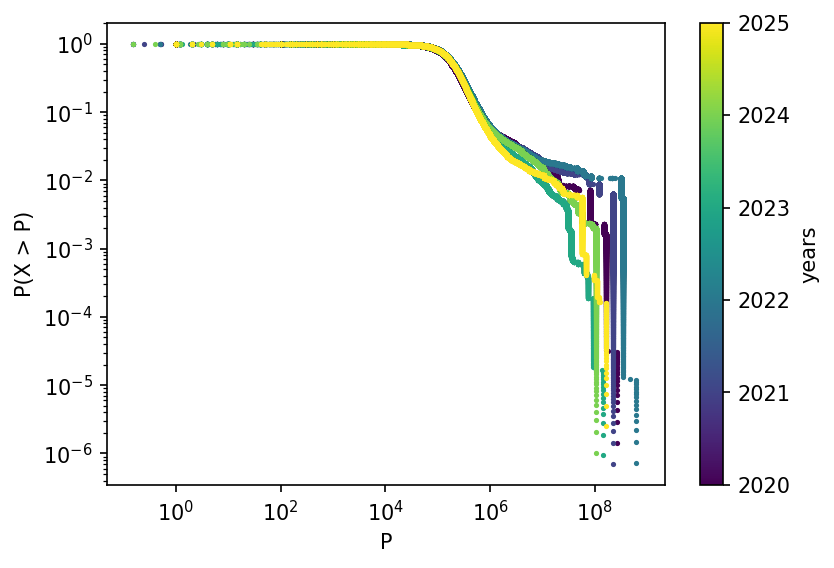

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# CCDF of valeur_fonciere by year
df_plot = dvf_df.dropna(subset=["date_mutation", "valeur_fonciere"]).copy()
df_plot["year"] = df_plot["date_mutation"].dt.year

years = sorted(df_plot["year"].dropna().unique())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=150)

for i, year in enumerate(years):
    values = df_plot.loc[df_plot["year"] == year, "valeur_fonciere"].values
    if values.size == 0:
        continue
    values = np.sort(values)
    ccdf = 1.0 - (np.arange(1, values.size + 1) / values.size)
    ax.loglog(values, ccdf, marker='.', linestyle='None', ms=3, color=cmap(i / max(len(years) - 1, 1)))

norm = plt.Normalize(min(years), max(years))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("years")

ax.set_xlabel("P")
ax.set_ylabel("P(X > P)")
ax.grid(False)
plt.show()


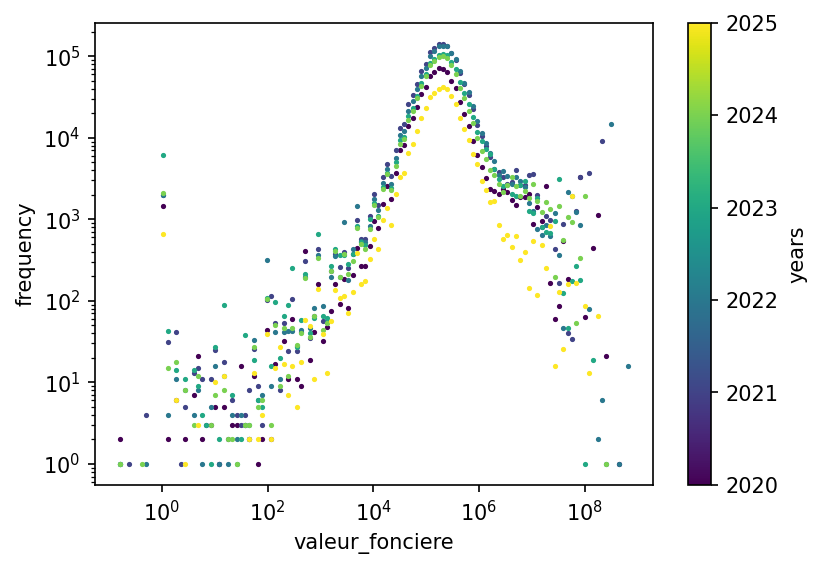

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Absolute frequency (histogram counts) of valeur_fonciere by year
df_plot = dvf_df.dropna(subset=["date_mutation", "valeur_fonciere"]).copy()
df_plot["year"] = df_plot["date_mutation"].dt.year

years = sorted(df_plot["year"].dropna().unique())
cmap = plt.cm.viridis

values_all = df_plot["valeur_fonciere"].values
values_all = values_all[values_all > 0]
bins = np.logspace(np.log10(values_all.min()), np.log10(values_all.max()), 120)
bin_centers = (bins[:-1] * bins[1:]) ** 0.5

fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=150)

for i, year in enumerate(years):
    values = df_plot.loc[df_plot["year"] == year, "valeur_fonciere"].values
    values = values[values > 0]
    if values.size == 0:
        continue
    counts, _ = np.histogram(values, bins=bins)
    ax.loglog(bin_centers, counts, marker='.', linestyle='None', ms=3, color=cmap(i / max(len(years) - 1, 1)))

norm = plt.Normalize(min(years), max(years))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("years")

ax.set_xlabel("valeur_fonciere")
ax.set_ylabel("frequency")
ax.set_xlim(1e3, 1e8)
ax.grid(False)
plt.show()


In [10]:
dvf_df["valeur_fonciere"].describe()

count    5.935901e+06
mean     2.007987e+06
std      1.937653e+07
min      1.500000e-01
25%      1.200000e+05
50%      1.980000e+05
75%      3.300000e+05
max      7.225900e+08
Name: valeur_fonciere, dtype: float64